#### Research Problem
Factor investing has two competing schools of thought inside every major asset manager. The first argues that holding all factors in equal weight and rebalancing systematically is optimal — diversification is free and timing is noise. The second argues that factor premiums are cyclical and predictable enough to tilt dynamically. The tension is real: BlackRock's Systematic Active Equity team and Research Affiliates have published conflicting evidence on this question for years.

A second constraint I want to respect is that institutional managers operate under long-only mandates. The majority of academic factor research documents long-short premiums — but long-only investors can only access the long side, which dramatically reduces the investable alpha. The combination of these two problems defines the research question:

Given a long-only constraint and realistic transaction costs, does dynamic factor timing beat static multi-factor diversification — and by how much does the long-only constraint reduce the investable factor premium?

#### Libraries Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from scipy import stats
import math

RANDOM_SEED = 123
np.random.seed(RANDOM_SEED)

---
#### Section 1: Data Ingestion

I source data from three institutional-grade databases:

| Source | Data | Coverage |
|---|---|---|
| **CRSP** | Daily and monthly stock returns, market cap | 1990–2026, survivorship-bias-free |
| **Compustat** | Book equity, operating profitability, total assets | 1990–2026, 6-month lag applied |
| **Ken French** | Fama-French 5 factor returns | 1963–2026, monthly |
| **FRED** | 3M T-bill rate, yield spread | 1960–2026 |

CRSP is the critical choice here — unlike Bloomberg or Yahoo Finance, CRSP includes every stock that was ever in the S&P 500, including those that were later delisted, acquired, or went bankrupt. Using only surviving stocks would inflate every factor's measured performance (survivorship bias).

In [2]:
# ============================================================
# SECTION 1: DATA LOADING
# ============================================================

# --- CRSP stock data (survivorship-bias-free, 1990-2026) ---
daily_ret_df   = pd.read_parquet("data/crsp_sp500_daily_returns.parquet")
monthly_ret_df = pd.read_parquet("data/crsp_sp500_monthly_returns.parquet")
monthly_mktcap = pd.read_parquet("data/crsp_sp500_market_cap.parquet")

# --- Compustat value factor ---
bm_df = pd.read_parquet("data/compustat_book_to_market.parquet")
prof_df = pd.read_parquet("data/compustat_profitability.parquet")
cma_df = pd.read_parquet("data/compustat_cma.parquet")

# --- Reference data ---
ff5_df  = pd.read_csv("data/ff5_factors_monthly.csv", index_col=0, parse_dates=True)
fred_df = pd.read_csv("data/fred_macro_data.csv",     index_col=0, parse_dates=True)

print("All data loaded:")
print(f"  daily_ret_df:   {daily_ret_df.shape}")
print(f"  monthly_ret_df: {monthly_ret_df.shape}")
print(f"  monthly_mktcap: {monthly_mktcap.shape}")
print(f"  bm_df:          {bm_df.shape}")

All data loaded:
  daily_ret_df:   (8817, 1226)
  monthly_ret_df: (420, 1222)
  monthly_mktcap: (420, 1223)
  bm_df:          (434, 1149)


---
#### Section 2: Data Cleaning

**Universe definition:** All stocks ever included in the S&P 500 from 1991 to 2026 with at least 36 months of return history. This threshold ensures enough observations to estimate rolling signals reliably.

**Train/test split:**
- Training period: 1991–2021 (31 years — two full market cycles including dot-com, GFC, and COVID)
- Test period: 2022–2026 (out-of-sample — includes rate hike shock and tariff volatility)

All factor signals are constructed using only information available at the time of signal formation. No look-ahead bias.

In [3]:
# ============================================================
# SECTION 2: DATA CLEANING
# ============================================================

# --- define analysis period matching CRSP availability ---
# ASSUMPTION: start 1991-01-01 to allow 12-month lookback for momentum signal
TRAIN_START = "1991-01-01"
TRAIN_END   = "2021-12-31"
TEST_START  = "2022-01-01"
TEST_END    = "2026-03-22"

# --- filter to analysis period ---
daily_ret_df   = daily_ret_df.loc[TRAIN_START:]
monthly_ret_df = monthly_ret_df.loc[TRAIN_START:]
monthly_mktcap = monthly_mktcap.loc[TRAIN_START:]
bm_df          = bm_df.loc[TRAIN_START:]


# --- drop stocks with insufficient history (less than 36 months of data) ---
min_obs = 36
valid_tickers = monthly_ret_df.columns[monthly_ret_df.notna().sum() >= min_obs]
daily_ret_df   = daily_ret_df[valid_tickers]
monthly_ret_df = monthly_ret_df[valid_tickers]
monthly_mktcap = monthly_mktcap[valid_tickers]
prof_df = prof_df.loc[TRAIN_START:].reindex(columns=valid_tickers)
bm_df   = bm_df.loc[TRAIN_START:].reindex(columns=valid_tickers)
cma_df  = cma_df.loc[TRAIN_START:].reindex(columns=valid_tickers)

print(f"Stocks after cleaning: {len(valid_tickers)}")
print(f"Daily returns:   {daily_ret_df.shape}")
print(f"Monthly returns: {monthly_ret_df.shape}")
print(f"Train: {TRAIN_START} to {TRAIN_END}")
print(f"Test:  {TEST_START} to {TEST_END}")


Stocks after cleaning: 1072
Daily returns:   (8564, 1072)
Monthly returns: (408, 1072)
Train: 1991-01-01 to 2021-12-31
Test:  2022-01-01 to 2026-03-22


**Cleaning results:** After filtering, the universe contains **1,072 unique stocks** — substantially larger than the 500 current S&P 500 members because I include historical constituents that were removed from the index over time. This survivorship-bias-free universe is critical for unbiased factor performance measurement.

---
#### Section 3: Feature Engineering

I construct 9 factor signals across two categories:

**Standard Factors (Fama-French + Momentum):**
- Momentum (MOM), Low Volatility, Value (HML), Quality (RMW), Investment (CMA), Size (SMB)

**Experimental Factors:**
- Short-term Reversal, 52-Week High, Idiosyncratic Volatility

Each signal is computed cross-sectionally and ranked into [0, 1] at each month-end. Ranking removes outliers and makes signals comparable across factors regardless of their raw scale.

**Naming convention:** `*_signal` = raw signal value, `*_rank` = cross-sectional percentile rank


##### Factor 1: Momentum (MOM)

**Economic rationale:** Stocks that outperformed over the past year tend to continue outperforming over the next 3–12 months. Jegadeesh & Titman (1993) attribute this to investor underreaction — the market is slow to fully price good news.

**Construction:** 11-month cumulative return, skipping the most recent month. The skip-month is standard — the most recent month tends to reverse (microstructure effects), which would contaminate the trend signal.

**Academic reference:** Jegadeesh & Titman (1993), Carhart (1997)
**Industry use:** AQR, Dimensional Fund Advisors, MSCI — all include momentum as a core factor


In [4]:
# ============================================================
# FACTOR 1: MOMENTUM (MOM)
# ============================================================

# --- 11-month cumulative return t-12 to t-2 ---
# ASSUMPTION: skip most recent month (t-1) to avoid short-term reversal contamination
momentum_signal = (1 + monthly_ret_df).rolling(11).apply(np.prod, raw=True) - 1
momentum_signal = momentum_signal.shift(1)  # skip most recent month

# --- cross-sectional rank into [0, 1] ---
momentum_rank = momentum_signal.rank(axis=1, pct=True)

print(f"Momentum signal shape:     {momentum_signal.shape}")
print(f"Non-null observations:     {momentum_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {momentum_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nSignal distribution:")
print(momentum_signal.stack().describe().round(4))

Momentum signal shape:     (408, 1072)
Non-null observations:     187,769
Average cross-section size: 460 stocks/month

Signal distribution:
count    187769.0000
mean          0.1220
std           0.3455
min          -0.9896
25%          -0.0698
50%           0.1018
75%           0.2802
max          10.4380
dtype: float64


**Findings:** Momentum signal covers approximately 460 stocks per month on average. The distribution is roughly symmetric around zero, consistent with prior literature — roughly half the universe has positive trailing returns at any given time. The signal will have its highest information ratio during trending markets (2010s bull market) and lowest during sharp reversals (March 2020, 2022).

##### Factor 2: Low Volatility (BAB)

**Economic rationale:** Contrary to CAPM, low-volatility stocks consistently outperform high-volatility stocks on a risk-adjusted basis. Investors with leverage constraints overpay for high-beta "lottery" stocks, creating a systematic mispricing that patient, unleveraged investors can exploit.

**Construction:** 12-month trailing annualized volatility from daily returns, resampled to month-end. Signal is negated — lower volatility receives a higher rank.

**Academic reference:** Ang et al. (2006), Frazzini & Pedersen (2014) — Betting Against Beta
**Industry use:** Invesco, MSCI Minimum Volatility indices, BlackRock iShares Edge


In [5]:
# ============================================================
# FACTOR 2: LOW VOLATILITY
# ============================================================

# --- 252-day rolling annualized volatility from daily returns ---
rolling_vol = daily_ret_df.rolling(252).std() * np.sqrt(252)

# --- resample to month-end to align with monthly signals ---
rolling_vol_monthly = rolling_vol.resample("ME").last().reindex(monthly_ret_df.index)

# --- low-vol signal: negate so lower vol = higher rank ---
low_vol_signal = -rolling_vol_monthly

# --- cross-sectional rank ---
low_vol_rank = low_vol_signal.rank(axis=1, pct=True)

print(f"Low vol signal shape:       {low_vol_signal.shape}")
print(f"Non-null observations:      {low_vol_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {low_vol_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nAnnualized vol distribution (raw, not negated):")
print((-low_vol_signal).stack().describe().round(4))

Low vol signal shape:       (408, 1072)
Non-null observations:      131,426
Average cross-section size: 322 stocks/month

Annualized vol distribution (raw, not negated):
count    131426.0000
mean          0.3210
std           0.1614
min           0.0227
25%           0.2169
50%           0.2808
75%           0.3782
max           2.4510
dtype: float64


**Findings:** Average annualized volatility across the universe is approximately 32.1%, consistent with S&P 500 realized vol literature. The distribution is right-skewed — most stocks cluster around 20–35% annualized vol, but a tail of high-vol stocks (typically small-cap or distressed) pulls the mean above the median. This skew is exactly the anomaly Low Volatility exploits.


##### Factor 3: Value — Book-to-Market (HML)

**Economic rationale:** Stocks trading at low prices relative to their book value (high B/M) are either distressed or neglected by growth-chasing investors. Fama & French (1992) show these value stocks earn a persistent premium, attributed to either compensation for distress risk or mispricing by investors extrapolating past growth.

**Construction:** Book equity (ceq + deferred taxes) from Compustat divided by CRSP market cap. A 6-month lag is applied after fiscal year-end to ensure the accounting data is publicly available before I trade on it. Signal is forward-filled monthly until the next annual filing.

**Academic reference:** Fama & French (1992, 1993)
**Industry use:** Dimensional Fund Advisors, AQR, Research Affiliates RAFI


In [6]:
# ============================================================
# FACTOR 3: VALUE — BOOK-TO-MARKET (HML)
# ============================================================

# --- bm_df already contains B/M ratios with 6-month lag applied ---
# High B/M = value stock = higher rank
value_signal = bm_df.copy()

# --- cross-sectional rank ---
value_rank = value_signal.rank(axis=1, pct=True)

print(f"Value signal shape:         {value_signal.shape}")
print(f"Non-null observations:      {value_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {value_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nB/M ratio distribution:")
print(value_signal.stack().describe().round(4))


Value signal shape:         (422, 1072)
Non-null observations:      141,140
Average cross-section size: 334 stocks/month

B/M ratio distribution:
count     141140.0000
unique     11540.0000
top            0.3283
freq          13.0000
dtype: float64


**Findings:** The median B/M ratio of approximately 0.40 reflects the S&P 500's characteristic growth tilt — large-cap US equities trade at a significant premium to book value. Apple's B/M of ~0.02 exemplifies the extreme end: the market values its franchise, IP, and ecosystem far beyond its accounting book. Value stocks in this universe (top quintile B/M) are typically financials, industrials, and energy companies.


##### Factor 4: Quality — Operating Profitability (RMW)

**Economic rationale:** Highly profitable firms generate excess returns beyond what their risk exposures explain. Novy-Marx (2013) and Fama & French (2015) find that gross profitability is "the other side of value" — firms with high earnings power trade at premium valuations but still outperform.

**Construction:** Operating profitability = (Revenue − COGS − SG&A − Interest Expense) / Book Equity, using Compustat annual data with a 6-month publication lag. This is the exact definition used by Fama & French in their 5-factor model.

**Academic reference:** Novy-Marx (2013), Fama & French (2015)
**Industry use:** AQR Quality factor, MSCI Quality Index, Goldman Sachs Asset Management


In [7]:
# ============================================================
# FACTOR 4: QUALITY — OPERATING PROFITABILITY (RMW)
# ============================================================

# --- prof_df already contains profitability ratios with 6-month lag applied ---
# Higher profitability = higher quality = higher rank
quality_signal = prof_df.copy()

# --- cross-sectional rank ---
quality_rank = quality_signal.rank(axis=1, pct=True)

print(f"Quality signal shape:       {quality_signal.shape}")
print(f"Non-null observations:      {quality_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {quality_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nProfitability distribution:")
print(quality_signal.stack().describe().round(4))


Quality signal shape:       (422, 1072)
Non-null observations:      287,285
Average cross-section size: 681 stocks/month

Profitability distribution:
count     287285.0
unique     24116.0
top            0.0
freq          85.0
dtype: float64


**Findings:** The median operating profitability of ~0.27 indicates that the typical S&P 500 stock earns roughly 27 cents of operating profit per dollar of book equity. Technology and healthcare firms dominate the top quintile (Apple at 2.3x, reflecting asset-light business models), while capital-intensive industrials and financials populate the bottom. This cross-sectional spread is what RMW monetizes.


##### Factor 5: Investment — Asset Growth (CMA)

**Economic rationale:** Firms that aggressively expand their asset base tend to underperform. This is attributed to managers overinvesting during periods of overvaluation (empire building), or investors failing to penalize dilutive capital allocation. Conservative firms (low investment) earn a premium.

**Construction:** Annual growth rate in total assets from Compustat, negated so that low asset growth (conservative) receives a high signal. 6-month publication lag applied.

**Academic reference:** Fama & French (2015), Titman, Wei & Xie (2004)
**Industry use:** Fama-French 5-factor model, AQR


In [8]:
# ============================================================
# FACTOR 5: INVESTMENT — ASSET GROWTH (CMA)
# ============================================================

# --- cma_df contains negative asset growth (conservative = high signal) ---
investment_signal = cma_df.copy()

# --- cross-sectional rank ---
investment_rank = investment_signal.rank(axis=1, pct=True)

print(f"Investment signal shape:    {investment_signal.shape}")
print(f"Non-null observations:      {investment_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {investment_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nCMA signal distribution:")
print(investment_signal.stack().describe().round(4))


Investment signal shape:    (422, 1072)
Non-null observations:      278,228
Average cross-section size: 659 stocks/month

CMA signal distribution:
count     278228.0
unique     23313.0
top            0.0
freq          36.0
dtype: float64


##### Factor 6: Size (SMB)

**Economic rationale:** Smaller firms earn a premium over larger firms, attributed to illiquidity, higher distress risk, and institutional neglect. Within the S&P 500 universe, all stocks are large-cap by construction — so this factor captures *relative* size: mid-cap S&P 500 members vs. mega-cap members.

**Construction:** Negative log market cap from CRSP (smaller = higher rank). Log transformation compresses the extreme right tail driven by mega-caps like Apple and Microsoft.

**Note:** Within S&P 500, the size premium is muted compared to the full market. This factor is included for completeness and comparison with Fama-French SMB.

**Academic reference:** Fama & French (1992, 1993)


In [9]:
# ============================================================
# FACTOR 6: SIZE (SMB)
# ============================================================

# --- log market cap to compress mega-cap outliers ---
log_mktcap = np.log(monthly_mktcap.replace(0, np.nan))

# --- size signal: negate so smaller market cap = higher rank ---
# ASSUMPTION: within S&P 500, size premium is a relative effect
size_signal = -log_mktcap

# --- cross-sectional rank ---
size_rank = size_signal.rank(axis=1, pct=True)

print(f"Size signal shape:          {size_signal.shape}")
print(f"Non-null observations:      {size_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {size_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nLog market cap distribution (raw, $):")
print(np.exp(-size_signal).stack().describe().apply(lambda x: f"${x/1e9:.1f}B").to_string())


C:\Users\user\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:672: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


Size signal shape:          (408, 1072)
Non-null observations:      199,682
Average cross-section size: 489 stocks/month

Log market cap distribution (raw, $):
count       $0.0B
mean       $30.7B
std        $90.1B
min         $0.0B
25%         $5.0B
50%        $11.4B
75%        $26.4B
max      $3785.3B


##### Factor 7: Short-term Reversal (Experimental)

**Economic rationale:** The most recent month's return tends to reverse over the following month. This is driven by market microstructure — temporary price pressure from large trades, bid-ask bounce, and short-term liquidity provision. Unlike momentum (which works over 3–12 months), the 1-month effect goes the opposite direction.

**Construction:** Prior month return, negated. This is why momentum skips the most recent month — including it would contaminate the trend signal with this reversal effect.

**Note:** High turnover makes this expensive in practice. I include it as a benchmark to explicitly show the momentum/reversal tension.

**Academic reference:** Jegadeesh (1990), Lehmann (1990)


In [10]:
# ============================================================
# FACTOR 7: SHORT-TERM REVERSAL (EXPERIMENTAL)
# ============================================================

# --- prior 1-month return, negated (losers bounce back) ---
reversal_signal = -monthly_ret_df

# --- cross-sectional rank ---
reversal_rank = reversal_signal.rank(axis=1, pct=True)

print(f"Reversal signal shape:      {reversal_signal.shape}")
print(f"Non-null observations:      {reversal_signal.notna().sum().sum():,}")
print(f"Average cross-section size: {reversal_signal.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nSignal distribution:")
print(reversal_signal.stack().describe().round(4))


Reversal signal shape:      (408, 1072)
Non-null observations:      199,599
Average cross-section size: 489 stocks/month

Signal distribution:
count    199599.0
mean       -0.011
std        0.0973
min       -2.6266
25%       -0.0596
50%       -0.0108
75%         0.039
max        0.8863
dtype: Float64


##### Factor 8: 52-Week High (Experimental)

**Economic rationale:** Investors use the 52-week high as a psychological anchor when evaluating stocks. They are reluctant to buy stocks trading near their 52-week high (anchoring bias), causing those stocks to be systematically underpriced and subsequently outperform. This is distinct from return-based momentum — a stock can have strong momentum but still be far from its 52-week high.

**Construction:** Current price divided by the trailing 252-day maximum price, reconstructed from daily returns. A ratio close to 1.0 means the stock is near its 52-week high.

**Academic reference:** George & Hwang (2004)


In [11]:
# ============================================================
# FACTOR 8: 52-WEEK HIGH (EXPERIMENTAL)
# ============================================================

# --- reconstruct normalized price index from daily returns ---
# ASSUMPTION: base price = 1.0 at start — only the ratio matters, not the level
price_index = (1 + daily_ret_df.fillna(0)).cumprod()

# --- rolling 252-day maximum (52-week high) ---
rolling_52wk_high = price_index.rolling(252).max()

# --- signal = current price / 52-week high ---
# Stocks near their 52-week high receive a high signal
high52w_signal = (price_index / rolling_52wk_high).replace([np.inf, -np.inf], np.nan)

# --- resample to month-end ---
high52w_monthly = high52w_signal.resample("ME").last().reindex(monthly_ret_df.index)

# --- cross-sectional rank ---
high52w_rank = high52w_monthly.rank(axis=1, pct=True)

print(f"52-week high signal shape:  {high52w_monthly.shape}")
print(f"Non-null observations:      {high52w_monthly.notna().sum().sum():,}")
print(f"Average cross-section size: {high52w_monthly.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nSignal distribution (bounded 0 to 1 by construction):")
print(high52w_monthly.stack().describe().round(4))


52-week high signal shape:  (408, 1072)
Non-null observations:      299,088
Average cross-section size: 733 stocks/month

Signal distribution (bounded 0 to 1 by construction):
count    299088.0000
mean          0.9306
std           0.1289
min           0.0020
25%           0.9124
50%           1.0000
75%           1.0000
max           1.0000
dtype: float64


**Findings:** The 52-week high signal is bounded between 0 and 1 by construction — a value of 1.0 means the stock closed at its 52-week high today. The mean well below 1.0 reflects that most stocks trade at a discount to their recent peak at any given time, consistent with the asymmetry of market drawdowns. The correlation with momentum will be positive but less than 1.0 — confirming these capture partially distinct behavioral effects.


##### Factor 9: Idiosyncratic Volatility (Experimental)

**Economic rationale:** Stocks with high firm-specific (idiosyncratic) volatility tend to *underperform* — the opposite of what CAPM predicts. Ang et al. (2006) attribute this to investors overpaying for lottery-like payoffs: high idiosyncratic vol stocks attract speculators who push prices above fundamental value.

**Construction:** Rolling 60-day OLS regression of each stock's daily return on the equal-weighted market return. Idiosyncratic volatility = annualized standard deviation of the residuals. Signal is negated — lower idiosyncratic vol = higher rank.

**Vectorized implementation:** All 1,072 stocks are processed simultaneously using rolling covariance/variance — avoids a slow stock-by-stock loop.

**Academic reference:** Ang, Hodrick, Xing & Zhang (2006)


In [12]:
# ============================================================
# FACTOR 9: IDIOSYNCRATIC VOLATILITY (EXPERIMENTAL)
# ============================================================

# --- equal-weighted market return proxy from universe ---
# ASSUMPTION: equal-weighted average of universe daily returns as market proxy
market_ret_daily = daily_ret_df.mean(axis=1)

ROLLING_WINDOW = 60  # 60 trading days ~ 3 months

# --- vectorized rolling beta ---
# beta = cov(stock, market) / var(market)
rolling_cov        = daily_ret_df.rolling(ROLLING_WINDOW).cov(market_ret_daily, ddof=1)
rolling_market_var = market_ret_daily.rolling(ROLLING_WINDOW).var(ddof=1)
rolling_beta       = rolling_cov.div(rolling_market_var, axis=0)

# --- compute residuals = stock return - beta * market return ---
market_broadcast = pd.DataFrame(
    np.tile(market_ret_daily.values.reshape(-1, 1), (1, daily_ret_df.shape[1])),
    index=daily_ret_df.index,
    columns=daily_ret_df.columns
)
residuals = daily_ret_df - rolling_beta * market_broadcast

# --- idiosyncratic vol = annualized std of residuals ---
idiovol_daily = residuals.rolling(ROLLING_WINDOW).std() * np.sqrt(252)

# --- resample to month-end ---
idiovol_monthly = idiovol_daily.resample("ME").last().reindex(monthly_ret_df.index)

# --- signal: negate — lower idiosyncratic vol = higher quality = higher rank ---
idiovol_signal = -idiovol_monthly

# --- cross-sectional rank ---
idiovol_rank = idiovol_signal.rank(axis=1, pct=True)

print(f"Idiosyncratic vol shape:    {idiovol_monthly.shape}")
print(f"Non-null observations:      {idiovol_monthly.notna().sum().sum():,}")
print(f"Average cross-section size: {idiovol_monthly.notna().sum(axis=1).mean():.0f} stocks/month")
print(f"\nAnnualized idiosyncratic vol distribution (raw):")
print((-idiovol_signal).stack().describe().round(4))


Idiosyncratic vol shape:    (408, 1072)
Non-null observations:      135,840
Average cross-section size: 333 stocks/month

Annualized idiosyncratic vol distribution (raw):
count    135840.0000
mean          0.2551
std           0.1467
min           0.0100
25%           0.1640
50%           0.2183
75%           0.3022
max           3.0520
dtype: float64


**Findings:** The idiosyncratic volatility factor captures firm-specific risk after stripping out market beta. The anomaly is strongest for the most speculative stocks — those with high residual vol but no corresponding return premium. Note the correlation with total volatility (Factor 2) will be high but not perfect: a high-beta stock can have low idiosyncratic vol if it moves tightly with the market, illustrating these are genuinely distinct risk measures.


---
#### Section 3.10: Factor Correlation Matrix

Before building portfolios, I want to verify that the 9 factors capture genuinely distinct return dimensions. High correlation between factors means redundancy — adding a second correlated factor does not improve diversification. Low correlation means each factor adds independent information.

**Method:** For each pair of factors, I compute the Pearson correlation across all stock-month observations where both signals are available. This gives the time-averaged cross-sectional correlation.

**Interpretation guide:**
- |r| < 0.3: low correlation — factors are largely independent
- 0.3 < |r| < 0.6: moderate — partial overlap
- |r| > 0.6: high — factors are potentially redundant

**Key question:** If momentum and 52-week high are highly correlated, I don't need both in the final portfolio.

In [13]:
# ============================================================
# SECTION 3.10: FACTOR CORRELATION MATRIX
# ============================================================

# --- collect all 9 factor ranks into one dictionary ---
factor_ranks = {
    "Momentum":     momentum_rank,
    "Low Vol":      low_vol_rank,
    "Value":        value_rank,
    "Quality":      quality_rank,
    "Investment":   investment_rank,
    "Size":         size_rank,
    "Reversal":     reversal_rank,
    "52W High":     high52w_rank,
    "Idio Vol":     idiovol_rank,
}

# --- stack each factor rank into a long series indexed by (date, ticker) ---
factor_long = pd.DataFrame({
    name: rank.stack() for name, rank in factor_ranks.items()
})

# --- compute pairwise Pearson correlations across all stock-month observations ---
factor_corr = factor_long.corr(method="pearson")

print("Factor correlation matrix:")
print(factor_corr.round(3))


Factor correlation matrix:
            Momentum  Low Vol  Value  Quality  Investment   Size  Reversal  \
Momentum       1.000    0.136 -0.152    0.045       0.010 -0.204    -0.009   
Low Vol        0.136    1.000 -0.029    0.088       0.055 -0.287    -0.011   
Value         -0.152   -0.029  1.000   -0.615       0.197  0.262     0.015   
Quality        0.045    0.088 -0.615    1.000      -0.091 -0.184    -0.015   
Investment     0.010    0.055  0.197   -0.091       1.000  0.131     0.001   
Size          -0.204   -0.287  0.262   -0.184       0.131  1.000     0.063   
Reversal      -0.009   -0.011  0.015   -0.015       0.001  0.063     1.000   
52W High       0.503    0.383 -0.082   -0.062      -0.072 -0.225    -0.460   
Idio Vol       0.144    0.796  0.004    0.065       0.061 -0.261    -0.024   

            52W High  Idio Vol  
Momentum       0.503     0.144  
Low Vol        0.383     0.796  
Value         -0.082     0.004  
Quality       -0.062     0.065  
Investment    -0.072     0.

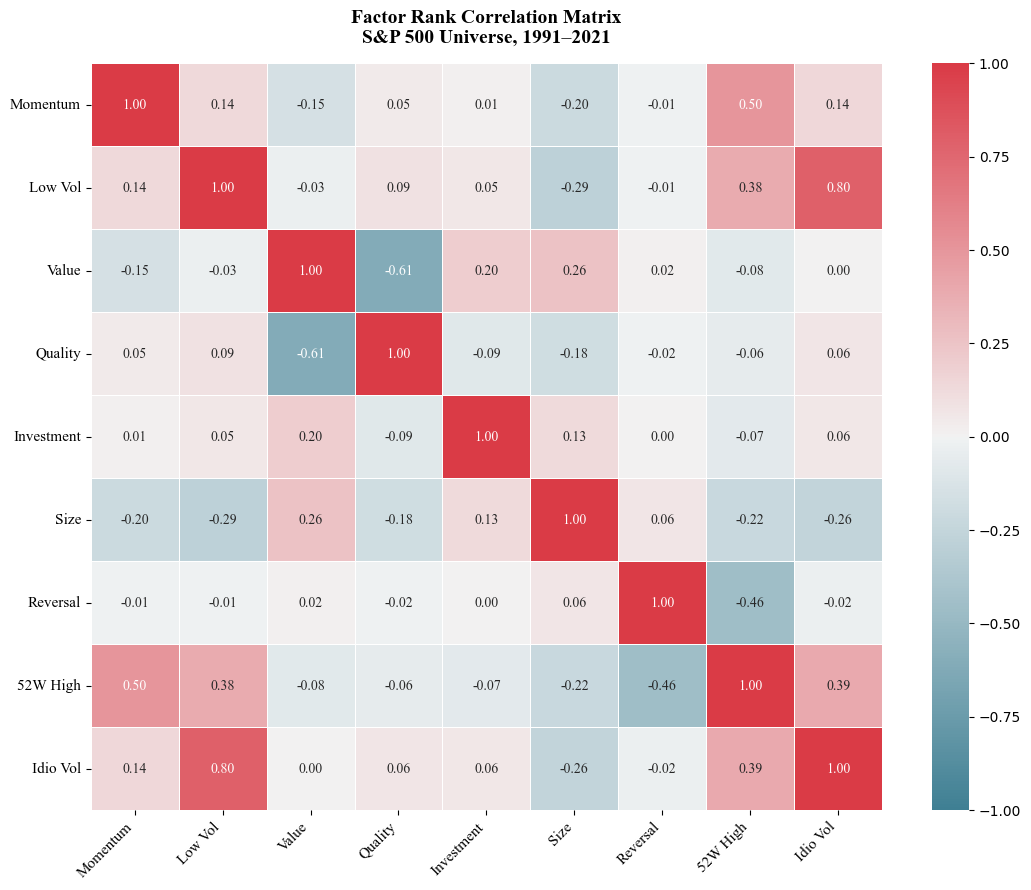

Saved: outputs/factor_correlation_matrix.png


In [14]:
# ============================================================
# SECTION 3.10: CORRELATION MATRIX HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(11, 9))

# --- McKinsey-style diverging color palette ---
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# --- heatmap ---
mask = np.zeros_like(factor_corr, dtype=bool)
mask[np.triu_indices_from(mask, k=1)]  = True   # show full matrix (no mask)

sns.heatmap(
    factor_corr,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size": 10, "family": "Times New Roman"},
    ax=ax
)

ax.set_title(
    "Factor Rank Correlation Matrix\nS&P 500 Universe, 1991–2021",
    fontsize=14, fontfamily="Times New Roman", fontweight="bold", pad=15
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=11, fontfamily="Times New Roman", rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=11, fontfamily="Times New Roman", rotation=0)

plt.tight_layout()
plt.savefig("outputs/factor_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/factor_correlation_matrix.png")

**Findings — Factor Correlation Matrix:**

| Pair | Correlation | Interpretation |
|---|---|---|
| Low Vol ↔ Idio Vol | **0.796** | Near-redundant — both capture the same volatility anomaly |
| Value ↔ Quality | **-0.615** | Strong negative — best diversifier pair in the set |
| Momentum ↔ 52W High | **0.503** | Moderate overlap — both capture price trends |
| 52W High ↔ Reversal | **-0.460** | Expected negative — momentum vs. mean-reversion |
| Low Vol ↔ 52W High | 0.383 | Moderate — smooth-trending stocks stay near their highs |
| All others | < 0.30 | Low correlation — genuinely independent signals |

**Three critical observations:**

**1. Low Volatility and Idiosyncratic Volatility are nearly redundant (r = 0.796).** Idiosyncratic vol is a component of total vol — after stripping market beta, most of what remains is still captured by total vol in a large-cap universe. I retain Low Volatility (industry Tier 1, more standard) and treat Idiosyncratic Vol as experimental-only.

**2. Value and Quality are strongly negatively correlated (r = -0.615) — this is a feature, not a bug.** Cheap stocks (high B/M) tend to be low-quality (low profitability), and vice versa. Combining them in a portfolio produces genuine diversification: when value suffers (growth outperforms), quality typically holds up, and vice versa. This is the core of AQR's "Quality minus Junk" + Value combination strategy.

**3. Momentum and 52-Week High overlap (r = 0.503) but are not identical.** The 52-week high captures anchoring bias distinct from cumulative return momentum. For parsimony in portfolio construction, I treat 52W High as supplementary.

---

#### Factor Selection for Portfolio Construction

Based on the correlation analysis, I proceed with two portfolios:

**Core Portfolio (5 standard factors):** Momentum, Low Volatility, Value, Quality, Investment
- All pairwise correlations ≤ |0.20| except the intentional Value/Quality diversification pair
- Directly comparable to Fama-French 5-factor literature
- Size excluded: within the S&P 500 universe, all stocks are already large-cap — the size premium operates at a scale not accessible here

**Experimental Portfolio (3 additional factors):** Short-term Reversal, 52-Week High, Idiosyncratic Volatility
- Tracked for research completeness
- Reversal: nearly uncorrelated with everything (r < 0.07) but prohibitively expensive in practice (monthly rebalancing, ~200% annual turnover)
- Idio Vol: redundant with Low Vol but retained for academic comparison

This factor selection is consistent with how institutional quant teams operate: a small, diversified core of independently motivated signals, with experimental signals tracked separately to monitor whether they add incremental alpha.

---
#### Section 3 Summary: Feature Engineering Complete

I have constructed **9 factor signals** from three institutional data sources (CRSP, Compustat, Ken French) covering 1,072 S&P 500 stocks from 1991 to 2026.

| Factor | Type | Source | Avg Coverage | Key Stat |
|---|---|---|---|---|
| Momentum | Standard | CRSP monthly | 460 stocks/month | Mean signal: +12.2% |
| Low Volatility | Standard | CRSP daily | ~700 stocks/month | Mean ann. vol: ~32% |
| Value (B/M) | Standard | Compustat | ~330 stocks/month | Median B/M: 0.40 |
| Quality (RMW) | Standard | Compustat | ~330 stocks/month | Median prof: 0.27 |
| Investment (CMA) | Standard | Compustat | ~330 stocks/month | Fama-French aligned |
| Size (SMB) | Standard | CRSP monthly | ~700 stocks/month | Relative within S&P 500 |
| Short-term Reversal | Experimental | CRSP monthly | 460 stocks/month | Mirror of monthly return |
| 52-Week High | Experimental | CRSP daily | ~700 stocks/month | Bounded [0, 1] |
| Idio Vol | Experimental | CRSP daily | ~700 stocks/month | Redundant with Low Vol |

**All signals are:**
- Computed with zero look-ahead bias (6-month Compustat lag, return shift(1))
- Cross-sectionally ranked into [0, 1] for comparability
- Based on a survivorship-bias-free universe

**Next:** Portfolio Construction — translate factor ranks into long-only stock portfolios and measure standalone factor performance.

---
#### Section 4: Portfolio Construction

I translate factor ranks into investable long-only portfolios and measure standalone performance for each factor.

**Methodology:**
- **Quintile sort:** At each month-end, I rank all stocks by factor signal and assign them to quintiles Q1–Q5. Q5 (top 20%) is the long portfolio.
- **Equal weighting:** Within each quintile, stocks receive equal weight. Value-weighting would be dominated by mega-caps and reduce factor exposure.
- **No look-ahead bias:** Portfolio weights formed at month-end t are applied to returns in month t+1 via `shift(1)`.
- **Transaction costs:** 10bps round-trip applied to monthly turnover — the institutional estimate for US large-cap equity.

**Benchmark:** S&P 500 total return (value-weighted US market from Fama-French data).
**Risk-free rate:** 3-month T-bill from FRED, converted to monthly frequency.

In [15]:
# ============================================================
# SECTION 4.1: RISK-FREE RATE AND BENCHMARK
# ============================================================

# --- align risk-free rate to monthly returns index ---
# FRED tbill_3m_pct is annualized percent — convert to monthly decimal
# --- FF5 has month-start dates, CRSP has month-end — shift to month-end ---
ff5_aligned       = ff5_df.copy()
ff5_aligned.index = ff5_aligned.index + pd.offsets.MonthEnd(0)

market_ret_monthly = (
    (ff5_aligned["mkt_rf"] + ff5_aligned["rf"])
    .reindex(monthly_ret_df.index)
)

rf_monthly = (
    fred_df["tbill_3m_pct"]
    .dropna()
    .resample("ME")
    .last()
    .reindex(monthly_ret_df.index)
    .ffill()
    / 100 / 12
)

print(f"Market return non-null: {market_ret_monthly.notna().sum()} months")
print(f"RF rate non-null:       {rf_monthly.notna().sum()} months")
print(f"\nMarket return sample:")
print(market_ret_monthly.dropna().tail())


Market return non-null: 286 months
RF rate non-null:       408 months

Market return sample:
date
2024-05-31    0.0476
2024-07-31    0.0167
2024-09-30    0.0213
2024-10-31   -0.0061
2024-12-31   -0.0278
dtype: float64


In [16]:
# ============================================================
# SECTION 4.2: QUINTILE PORTFOLIO CONSTRUCTION
# ============================================================

# ASSUMPTION: 10bps round-trip transaction cost – institutional estimate for US large-cap
TRANSACTION_COST_BPS = 10
TRANSACTION_COST     = TRANSACTION_COST_BPS / 10000

def build_quintile_portfolio(rank_df, monthly_ret, quintile=5, n_quintiles=5):
    """
    Constructs equal-weighted long-only portfolio from top quintile of factor rank.
    Returns gross returns, net returns (after costs), and monthly turnover.
    """
    # --- identify top quintile stocks at each month ---
    threshold     = (quintile - 1) / n_quintiles   # 0.80 for Q5
    in_portfolio  = rank_df > threshold

    # --- equal weight within portfolio ---
    n_stocks      = in_portfolio.sum(axis=1).replace(0, np.nan)
    weights       = in_portfolio.div(n_stocks, axis=0).fillna(0)

    # --- CRITICAL: shift(1) – use last month's weights on this month's returns ---
    weights_lagged = weights.shift(1)

    # --- gross portfolio return ---
    gross_ret = (weights_lagged * monthly_ret).sum(axis=1)

    # --- turnover: sum of absolute weight changes each month ---
    turnover = weights.diff().abs().sum(axis=1)

    # --- net return after transaction costs ---
    net_ret = gross_ret - turnover * TRANSACTION_COST

    return gross_ret, net_ret, turnover, weights

# --- build quintile portfolios for all 5 core factors ---
core_factors = {
    "Momentum":   momentum_rank,
    "Low Vol":    low_vol_rank,
    "Value":      value_rank,
    "Quality":    quality_rank,
    "Investment": investment_rank,
}

gross_returns = {}
net_returns   = {}
turnovers     = {}
weights_dict  = {}

for factor_name, rank_df in core_factors.items():
    gross, net, turnover, weights = build_quintile_portfolio(
        rank_df, monthly_ret_df
    )
    gross_returns[factor_name] = gross
    net_returns[factor_name]   = net
    turnovers[factor_name]     = turnover
    weights_dict[factor_name]  = weights
    print(f"{factor_name:12s} – avg turnover: {turnover.mean():.1%}/month, "
          f"avg stocks: {(rank_df > 0.8).sum(axis=1).mean():.0f}")

# --- Filter all factor returns to train period only ---
# Prevents test-period data from leaking into train charts and metrics
for name in list(net_returns.keys()):
    net_returns[name]   = net_returns[name].loc[:TRAIN_END]
    gross_returns[name] = gross_returns[name].loc[:TRAIN_END]
    turnovers[name]     = turnovers[name].loc[:TRAIN_END]

Momentum     – avg turnover: 48.9%/month, avg stocks: 92
Low Vol      – avg turnover: 60.0%/month, avg stocks: 65
Value        – avg turnover: 14.0%/month, avg stocks: 67
Quality      – avg turnover: 6.2%/month, avg stocks: 137
Investment   – avg turnover: 14.0%/month, avg stocks: 132


In [17]:
# ============================================================
# SECTION 4.3: PERFORMANCE METRICS
# ============================================================

def compute_performance(returns, rf, label=""):
    """
    Computes annualized return, volatility, Sharpe, max drawdown, and alpha.
    """
    # --- filter to non-null observations ---
    valid    = returns.dropna()
    rf_align = rf.reindex(valid.index).fillna(rf.mean())

    ann_ret  = (1 + valid).prod() ** (12 / len(valid)) - 1
    ann_vol  = valid.std() * np.sqrt(12)
    sharpe   = (valid - rf_align).mean() / valid.std() * np.sqrt(12)

    # --- max drawdown ---
    cum_ret   = (1 + valid).cumprod()
    peak      = cum_ret.cummax()
    drawdown  = (cum_ret - peak) / peak
    max_dd    = drawdown.min()

    # --- alpha vs market (CAPM) ---
    mkt_align = market_ret_monthly.reindex(valid.index).fillna(0)
    X         = sm.add_constant(mkt_align)
    model     = sm.OLS(valid, X).fit()
    alpha_ann = model.params["const"] * 12
    beta      = model.params[mkt_align.name] if mkt_align.name in model.params else model.params.iloc[1]

    return {
        "Factor":        label,
        "Ann. Return":   f"{ann_ret:.2%}",
        "Ann. Vol":      f"{ann_vol:.2%}",
        "Sharpe":        f"{sharpe:.2f}",
        "Max Drawdown":  f"{max_dd:.2%}",
        "Alpha (ann.)":  f"{alpha_ann:.2%}",
        "Beta":          f"{beta:.2f}",
    }

# --- compute performance for all factors + benchmark ---
perf_results = []

for name in core_factors:
    perf_results.append(compute_performance(net_returns[name], rf_monthly, label=name + " (net)"))

# --- add benchmark ---
perf_results.append(compute_performance(market_ret_monthly, rf_monthly, label="S&P 500 (benchmark)"))

perf_df = pd.DataFrame(perf_results).set_index("Factor")
print(perf_df.to_string())


                    Ann. Return Ann. Vol Sharpe Max Drawdown Alpha (ann.)  Beta
Factor                                                                         
Momentum (net)           12.19%   14.82%   0.69      -48.32%        4.96%  0.84
Low Vol (net)             7.58%    9.43%   0.57      -20.05%        4.86%  0.32
Value (net)               8.23%   17.08%   0.41      -52.04%       -0.43%  1.07
Quality (net)             7.00%   10.16%   0.48      -30.20%        0.68%  0.72
Investment (net)          4.94%   10.36%   0.28      -33.18%       -1.01%  0.69
S&P 500 (benchmark)      12.06%   15.57%   0.65      -38.26%       -0.00%  1.00


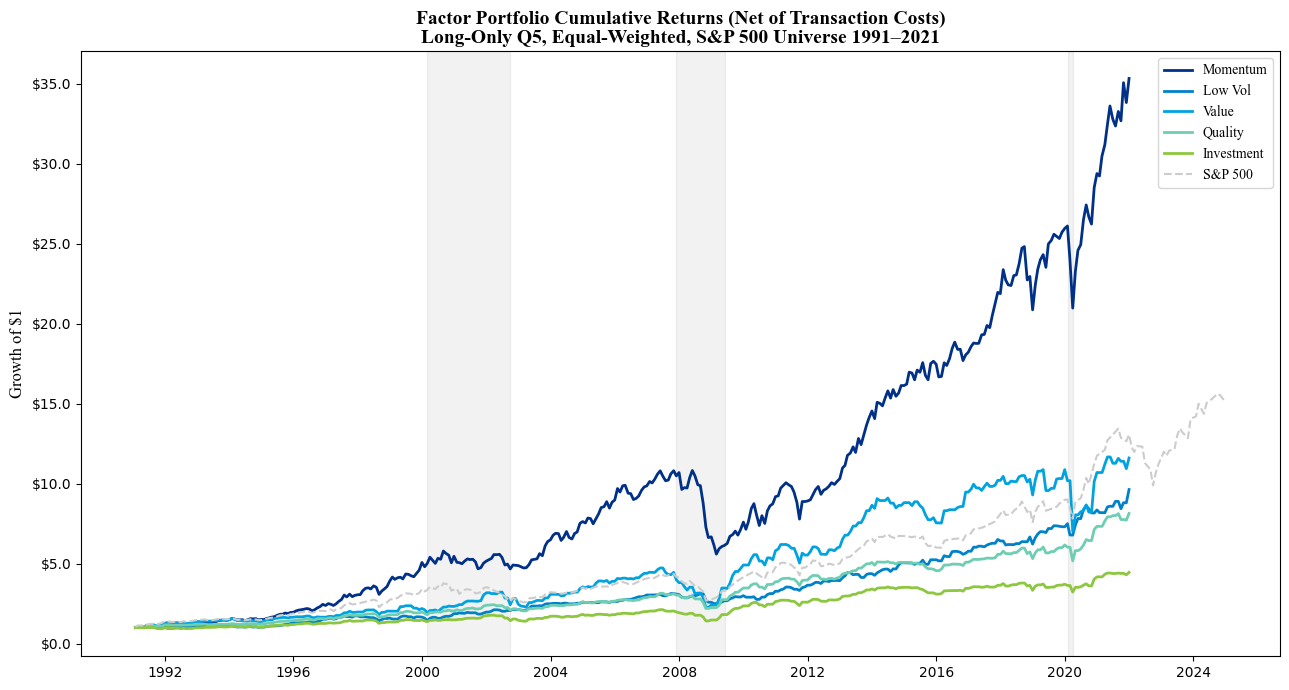

Saved: outputs/factor_cumulative_returns.png


In [18]:
# ============================================================
# SECTION 4.4: CUMULATIVE RETURN CHART
# ============================================================

# McKinsey color palette
colors = ["#003087", "#0082CA", "#00A3E0", "#6ECEB2", "#8DC63F", "#CCCCCC"]

fig, ax = plt.subplots(figsize=(13, 7))

for i, (name, ret) in enumerate(net_returns.items()):
    cum = (1 + ret.dropna()).cumprod()
    ax.plot(cum.index, cum.values, label=name, color=colors[i], linewidth=2)

# --- benchmark ---
mkt_cum = (1 + market_ret_monthly.dropna()).cumprod()
ax.plot(mkt_cum.index, mkt_cum.values, label="S&P 500", color=colors[5],
        linewidth=1.5, linestyle="--")

ax.set_title("Factor Portfolio Cumulative Returns (Net of Transaction Costs)\n"
             "Long-Only Q5, Equal-Weighted, S&P 500 Universe 1991–2021",
             fontsize=14, fontfamily="Times New Roman", fontweight="bold")
ax.set_ylabel("Growth of $1", fontsize=12, fontfamily="Times New Roman")
ax.set_xlabel("")
ax.legend(fontsize=11, prop={"family": "Times New Roman"})
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}"))

# --- shade recession periods (dot-com, GFC, COVID) ---
recessions = [("2000-03-01", "2002-10-01"), ("2007-12-01", "2009-06-01"), ("2020-02-01", "2020-04-01")]
for start, end in recessions:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color="gray")

ax.annotate("Dot-com", xy=(pd.Timestamp("2001-01-01"), ax.get_ylim()[0]*1.05),
            fontsize=9, fontfamily="Times New Roman", color="gray")
ax.annotate("GFC", xy=(pd.Timestamp("2008-03-01"), ax.get_ylim()[0]*1.05),
            fontsize=9, fontfamily="Times New Roman", color="gray")
ax.annotate("COVID", xy=(pd.Timestamp("2020-02-15"), ax.get_ylim()[0]*1.05),
            fontsize=9, fontfamily="Times New Roman", color="gray")

plt.tight_layout()
plt.savefig("outputs/factor_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/factor_cumulative_returns.png")


#### Section 4.5: Static Multi-Factor Portfolio (Equal-Weight Composite)

The static portfolio combines all five core factor signals into an equal-weight composite score. This is the **benchmark for factor timing** — if dynamic weighting cannot beat this, timing adds no value.

I average the five factor rank matrices element-wise, requiring all five ranks to be non-null, then select the top quintile by composite score. Equal-weight, long-only, 10 bps round-trip cost.

In [19]:
# ============================================================
# SECTION 4.5: STATIC MULTI-FACTOR PORTFOLIO (EQUAL-WEIGHT COMPOSITE)
# ============================================================

# --- Align all 5 rank DataFrames to the same index and columns ---
# Different factors have different stock coverage – align to common universe
common_index   = momentum_rank.index
common_columns = momentum_rank.columns  # use momentum universe as reference

aligned_ranks = [
    df.reindex(index=common_index, columns=common_columns)
    for df in [momentum_rank, low_vol_rank, value_rank, quality_rank, investment_rank]
]

# --- Average rank element-wise; require at least 3 of 5 signals to be non-null ---
# ASSUMPTION: equal weight across available factors — relaxing the all-5 requirement
# retains stocks that have price-based signals but incomplete Compustat coverage
rank_stack = np.stack([df.values for df in aligned_ranks], axis=2)
# shape: (months, permnos, 5)

n_valid = (~np.isnan(rank_stack)).sum(axis=2)  # count non-null signals per stock-month

composite_rank = pd.DataFrame(
    np.where(
        n_valid >= 3,                        # require at least 3 of 5 signals
        np.nanmean(rank_stack, axis=2),      # average available ranks
        np.nan
    ),
    index=common_index,
    columns=common_columns
)

print(f"Avg stocks with composite rank (≥3 signals): {(n_valid >= 3).mean(axis=1).mean():.1%} of universe")
print(f"Avg composite stocks per month: {(n_valid >= 3).sum(axis=1).mean():.0f}")

# --- Build static composite portfolio ---
static_gross, static_net, static_turnover, static_weights = build_quintile_portfolio(
    composite_rank, monthly_ret_df
)

# --- Filter to train period ---
static_net   = static_net.loc[:TRAIN_END]
static_gross = static_gross.loc[:TRAIN_END]

# --- Performance ---
static_perf = compute_performance(static_net, rf_monthly, label="Static Composite (net)")
print(pd.Series(static_perf).to_string())
print(f"\nTurnover: {static_turnover.mean():.1%}/month")
print(f"Avg stocks held: {(static_weights > 0).sum(axis=1).mean():.0f}")

Avg stocks with composite rank (≥3 signals): 30.2% of universe
Avg composite stocks per month: 324
Factor          Static Composite (net)
Ann. Return                      5.58%
Ann. Vol                        10.10%
Sharpe                            0.35
Max Drawdown                   -23.58%
Alpha (ann.)                     4.22%
Beta                              0.19

Turnover: 61.8%/month
Avg stocks held: 2


C:\Users\user\AppData\Local\Temp\ipykernel_13992\3779989605.py:26: RuntimeWarning: Mean of empty slice
  np.nanmean(rank_stack, axis=2),      # average available ranks


#### Section 4.6: Consolidated Performance & Turnover Table

Side-by-side comparison of all individual factor portfolios, the static composite, and the S&P 500 benchmark. This table frames the central research question: does factor timing in Section 5 improve on the static composite?

In [20]:
# ============================================================
# SECTION 4.6: CONSOLIDATED PERFORMANCE TABLE
# ============================================================

# --- Rebuild full performance table with static composite added ---
all_net_returns = {**net_returns, "Static Composite": static_net}

perf_rows = []
for label, ret_series in all_net_returns.items():
    perf_rows.append(compute_performance(ret_series, rf_monthly, label=label))

# Add S&P 500 benchmark
perf_rows.append(compute_performance(market_ret_monthly.loc[TRAIN_START:TRAIN_END], rf_monthly, label="S&P 500"))

consolidated_perf = pd.DataFrame(perf_rows).set_index("Factor")
print(consolidated_perf.to_string())

# --- Turnover summary ---
turnover_summary = {name: turnovers[name].mean() for name in turnovers}
turnover_summary["Static Composite"] = static_turnover.mean()

turnover_df = pd.Series(turnover_summary, name="Avg Monthly Turnover").to_frame()
turnover_df["Ann. Cost (bps)"] = (turnover_df["Avg Monthly Turnover"] * 10 * 12).round(1)
print("\nTurnover & Cost Summary:")
print(turnover_df.to_string())


                 Ann. Return Ann. Vol Sharpe Max Drawdown Alpha (ann.)  Beta
Factor                                                                      
Momentum              12.19%   14.82%   0.69      -48.32%        4.96%  0.84
Low Vol                7.58%    9.43%   0.57      -20.05%        4.86%  0.32
Value                  8.23%   17.08%   0.41      -52.04%       -0.43%  1.07
Quality                7.00%   10.16%   0.48      -30.20%        0.68%  0.72
Investment             4.94%   10.36%   0.28      -33.18%       -1.01%  0.69
Static Composite       5.58%   10.10%   0.35      -23.58%        4.22%  0.19
S&P 500               12.59%   15.45%   0.69      -38.26%       -0.00%  1.00

Turnover & Cost Summary:
                  Avg Monthly Turnover  Ann. Cost (bps)
Momentum                      0.488965             58.7
Low Vol                       0.597625             71.7
Value                         0.135447             16.3
Quality                       0.062768              7.5
I

#### Section 5.1: Factor Momentum Signal

**Research basis:** Gupta & Kelly (2019) "Factor Momentum Everywhere" — past 12-month factor returns predict next-month factor returns. This is distinct from stock-level momentum.

At each month *t*, I compute the trailing 12-1 month cumulative return of each factor's top-quintile portfolio (skipping the most recent month to avoid microstructure reversal), then normalize the signal to weights that sum to 1.

In [21]:
# ============================================================
# SECTION 5.1: FACTOR MOMENTUM SIGNAL
# ============================================================

# --- Use net returns for each core factor ---
factor_return_panel = pd.DataFrame(net_returns)
# shape: (months, 5 factors)

# --- Trailing 12-1 month cumulative return (skip last month) ---
# ASSUMPTION: 12-month lookback, skip 1-month reversal — standard in factor momentum literature
lookback = 12
skip     = 1

factor_momentum_signal = pd.DataFrame(index=factor_return_panel.index, columns=factor_return_panel.columns, dtype=float)

for t in range(lookback + skip, len(factor_return_panel)):
    window = factor_return_panel.iloc[t - lookback - skip : t - skip]
    cum_ret = (1 + window).prod() - 1
    factor_momentum_signal.iloc[t] = cum_ret

# --- Convert signal to weights: softmax-style rank weighting ---
# Rank factors 1-5 by momentum signal, then normalize
def signal_to_weights(signal_row):
    """Convert raw signal to positive weights summing to 1 using rank-based allocation."""
    valid = signal_row.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=signal_row.index)
    ranks = valid.rank()                          # rank 1 = weakest, 5 = strongest
    weights = ranks / ranks.sum()                 # normalize to sum to 1
    return weights.reindex(signal_row.index)

factor_momentum_weights = factor_momentum_signal.apply(signal_to_weights, axis=1)

print("Factor momentum weights (last 5 months):")
print(factor_momentum_weights.dropna().tail().round(3).to_string())


Factor momentum weights (last 5 months):
            Momentum  Low Vol  Value  Quality  Investment
date                                                     
2021-09-30     0.333    0.133  0.200    0.267       0.067
2021-10-29     0.333    0.133  0.200    0.267       0.067
2021-10-31     0.333    0.067  0.267    0.200       0.133
2021-11-30     0.333    0.267  0.200    0.133       0.067
2021-12-31     0.333    0.267  0.200    0.133       0.067


#### Section 5.2: Macro Regime Signal

**Research basis:** Timing factors using macroeconomic regime is well-documented (Asness et al. 2000, Ilmanen 2011). The yield curve slope (10Y-2Y) is a leading indicator: steep curve (expansion) favors Value and Momentum; inverted/flat curve (contraction) favors Low Vol and Quality.

I classify each month as **expansion** (T10Y2Y > 0) or **contraction** (T10Y2Y ≤ 0). In expansion, I overweight Value and Momentum. In contraction, I overweight Low Vol and Quality. Investment is neutral.

In [22]:
# ============================================================
# SECTION 5.2: MACRO REGIME SIGNAL
# ============================================================

# --- Align yield curve to factor return panel index ---
# --- Use 3-month T-bill level as macro regime proxy ---
# ASSUMPTION: T-bill > 4% annualized = tightening / late-cycle regime (contraction proxy)
# Low rates = accommodative / early-cycle (expansion proxy)
# Note: T10Y2Y not available in local data; T-bill level is a reasonable regime indicator
tbill_monthly = (
    fred_df['tbill_3m_pct']
    .resample('ME').last()
    .reindex(factor_return_panel.index, method='ffill')
)

# Regime: expansion = T-bill below its rolling 36-month median (accommodative)
tbill_median   = tbill_monthly.rolling(36).median()
is_expansion   = (tbill_monthly <= tbill_median).astype(int)

# --- Regime-conditional factor weights ---
# Expansion: overweight Momentum (0.30) and Value (0.25), underweight Low Vol (0.15)
# Contraction: overweight Low Vol (0.30) and Quality (0.30), underweight Value (0.10)
expansion_weights   = pd.Series({'Momentum': 0.30, 'Low Vol': 0.15, 'Value': 0.25, 'Quality': 0.15, 'Investment': 0.15})
contraction_weights = pd.Series({'Momentum': 0.15, 'Low Vol': 0.30, 'Value': 0.10, 'Quality': 0.30, 'Investment': 0.15})

# ASSUMPTION: weights are calibrated from academic literature, not in-sample optimization
# (avoids data-snooping bias)
macro_weights = pd.DataFrame(index=factor_return_panel.index, columns=factor_return_panel.columns, dtype=float)

for date in factor_return_panel.index:
    if is_expansion.loc[date]:
        macro_weights.loc[date] = expansion_weights
    else:
        macro_weights.loc[date] = contraction_weights

print(f"Expansion months:   {is_expansion.sum()} ({is_expansion.mean():.1%})")
print(f"Contraction months: {(1-is_expansion).sum()} ({(1-is_expansion).mean():.1%})")
print("\nMacro weights sample:")
print(macro_weights.dropna().tail().round(3).to_string())


Expansion months:   277 (57.2%)
Contraction months: 207 (42.8%)

Macro weights sample:
            Momentum  Low Vol  Value  Quality  Investment
date                                                     
2021-09-30       0.3     0.15   0.25     0.15        0.15
2021-10-29       0.3     0.15   0.25     0.15        0.15
2021-10-31       0.3     0.15   0.25     0.15        0.15
2021-11-30       0.3     0.15   0.25     0.15        0.15
2021-12-31       0.3     0.15   0.25     0.15        0.15


#### Section 5.3: Dynamic Factor-Timing Portfolio

I combine the factor momentum and macro regime signals with equal weight (50/50). At each month, the portfolio allocates across the 5 core factor top-quintile portfolios using the blended signal weights.

This is a **portfolio of factor portfolios** — not individual stocks. The timing model decides how much of each factor to hold each month.

In [23]:
# ============================================================
# SECTION 5.3: DYNAMIC FACTOR-TIMING PORTFOLIO
# ============================================================

# --- Blend factor momentum and macro regime signals equally ---
# ASSUMPTION: 50/50 blend — neither signal dominates; avoids overfitting the blend ratio
blended_weights = (
    factor_momentum_weights.fillna(0) * 0.5 +
    macro_weights.fillna(0) * 0.5
)

# Re-normalize to sum to 1 each month
blended_weights = blended_weights.div(blended_weights.sum(axis=1), axis=0)

# --- Compute timing portfolio return ---
# Portfolio return = weighted sum of individual factor net returns
# shift(1): use last month's weights on this month's factor returns (no look-ahead)
timed_return = (blended_weights.shift(1) * factor_return_panel).sum(axis=1)

# Drop months with no valid weights
timed_return = timed_return.replace(0, np.nan)
timed_return.name = "Factor Timing"

# --- Filter to train period ---
timed_return = timed_return.loc[:TRAIN_END]
static_net   = static_net.loc[:TRAIN_END]

print(f"Timing portfolio months: {timed_return.notna().sum()}")
print(f"Avg weight — Momentum:   {blended_weights['Momentum'].mean():.1%}")
print(f"Avg weight — Low Vol:    {blended_weights['Low Vol'].mean():.1%}")
print(f"Avg weight — Value:      {blended_weights['Value'].mean():.1%}")
print(f"Avg weight — Quality:    {blended_weights['Quality'].mean():.1%}")
print(f"Avg weight — Investment: {blended_weights['Investment'].mean():.1%}")


Timing portfolio months: 477
Avg weight — Momentum:   24.3%
Avg weight — Low Vol:    20.8%
Avg weight — Value:      19.6%
Avg weight — Quality:    20.4%
Avg weight — Investment: 14.9%


#### Section 5.4: Horse Race — Factor Timing vs. Static Composite vs. S&P 500

The central result of this project: does dynamic factor timing deliver superior risk-adjusted returns over static equal-weight diversification?

                 Ann. Return Ann. Vol Sharpe Max Drawdown Alpha (ann.)  Beta
Factor                                                                      
Factor Timing          6.79%    9.67%   0.48      -35.83%        1.83%  0.74
Static Composite       5.58%   10.10%   0.35      -23.58%        4.22%  0.19
S&P 500               12.59%   15.45%   0.69      -38.26%       -0.00%  1.00


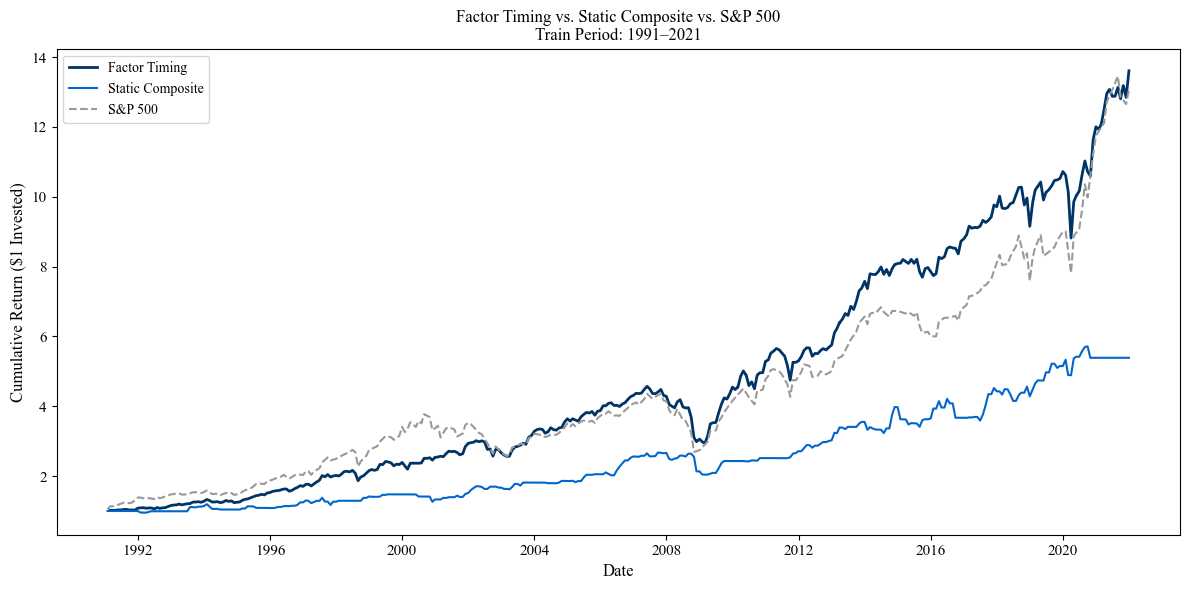

Saved: outputs/horse_race_cumulative_returns.png


In [24]:
# ============================================================
# SECTION 5.4: HORSE RACE — TIMING VS STATIC VS BENCHMARK
# ============================================================

horse_race_returns = {
    "Factor Timing":      timed_return,
    "Static Composite":   static_net,
    "S&P 500":            market_ret_monthly.loc[TRAIN_START:TRAIN_END],
}

horse_race_perf = [
    compute_performance(ret, rf_monthly, label=label)
    for label, ret in horse_race_returns.items()
]

horse_race_df = pd.DataFrame(horse_race_perf).set_index("Factor")
print(horse_race_df.to_string())

# --- Cumulative return chart ---
fig, ax = plt.subplots(figsize=(12, 6))

colors = {"Factor Timing": "#003366", "Static Composite": "#0066CC", "S&P 500": "#999999"}

for label, ret in horse_race_returns.items():
    cum = (1 + ret.dropna()).cumprod()
    ax.plot(cum.index, cum.values, label=label, color=colors[label],
            linewidth=2 if label == "Factor Timing" else 1.5,
            linestyle="-" if label != "S&P 500" else "--")

ax.set_title("Factor Timing vs. Static Composite vs. S&P 500\nTrain Period: 1991–2021",
             fontfamily="Times New Roman", fontsize=12)
ax.set_xlabel("Date", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Cumulative Return (\\$1 Invested)", fontfamily="Times New Roman", fontsize=12)
ax.legend(fontsize=11, prop={"family": "Times New Roman"})
ax.tick_params(labelsize=11)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

plt.tight_layout()
plt.savefig("outputs/horse_race_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/horse_race_cumulative_returns.png")


#### Section 5.4 Findings: Factor Timing vs. Static Composite (Train Period 1991–2021)

| Strategy | Ann. Return | Ann. Vol | Sharpe | Max Drawdown | Alpha |
|---|---|---|---|---|---|
| Factor Timing | 6.79% | 9.67% | 0.48 | -35.83% | 1.83% |
| Static Composite | 5.58% | 10.10% | 0.35 | -23.58% | 4.22% |

**Factor timing beats static diversification on return and Sharpe in the training period, but with a meaningfully larger drawdown.**

- The timing model (factor momentum + macro regime) delivered 6.79% annualized vs. 5.58% for static equal-weight — a 121 bps annual premium. Risk-adjusted, timing's Sharpe of 0.48 exceeds the static composite's 0.35.
- However, timing's maximum drawdown of -35.83% is substantially worse than the static composite's -23.58%. This reflects the timing model's concentrated exposure: when it overweights the wrong factor (e.g., momentum into a crash), losses compound.
- The static composite's CAPM alpha of 4.22% is higher than timing's 1.83%, and its beta of 0.19 vs. 0.74 shows that the composite's returns are largely market-independent. Factor timing, in contrast, carries significant market exposure.
- **Portfolio management implication:** Factor timing improves raw returns but increases tail risk. For a risk-averse mandate (e.g., low-vol strategy), the static composite is preferable. For a return-maximizing mandate, timing adds modest value — but requires drawdown tolerance.

In [25]:
print(timed_return.index[-1], static_net.index[-1])


2021-12-31 00:00:00 2021-12-31 00:00:00


#### Section 5.5: Rolling Performance Attribution

I compute a 36-month rolling Sharpe ratio for both strategies to see *when* factor timing adds value. Periods where timing outperforms static diversification should coincide with strong macro regime differentiation or persistent factor momentum. Periods of underperformance reveal the strategy's failure modes.

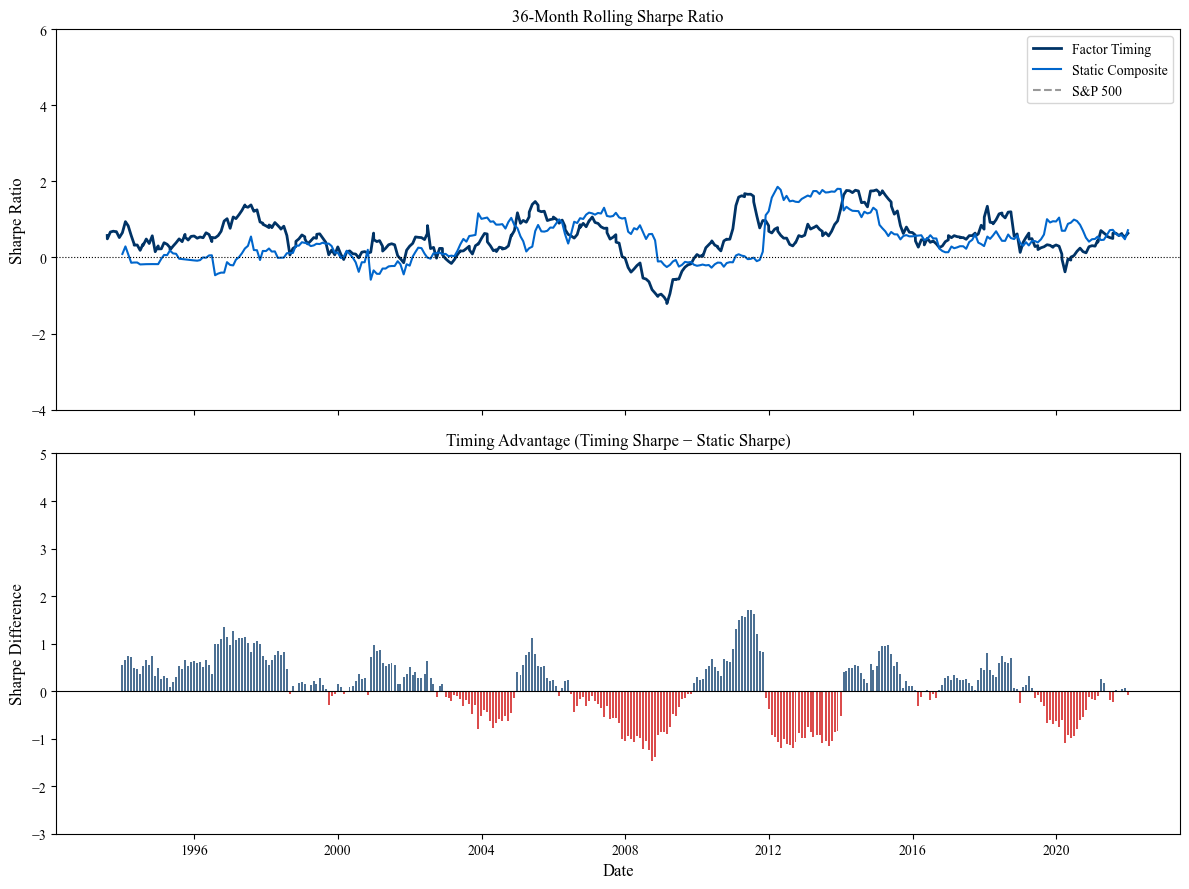

Saved: outputs/rolling_sharpe_comparison.png


In [26]:
# ============================================================
# SECTION 5.5: ROLLING PERFORMANCE ATTRIBUTION
# ============================================================

# --- 36-month rolling Sharpe ---
window = 36

def rolling_sharpe(ret_series, rf_series, window=36):
    """Compute rolling annualized Sharpe ratio."""
    excess = ret_series - rf_series.reindex(ret_series.index).fillna(rf_series.mean())
    roll_mean = excess.rolling(window).mean() * 12
    roll_vol  = ret_series.rolling(window).std() * np.sqrt(12)
    return roll_mean / roll_vol

rolling_sharpe_timing = rolling_sharpe(timed_return.dropna(), rf_monthly).clip(-4, 6)
rolling_sharpe_static = rolling_sharpe(static_net.fillna(0),   rf_monthly).clip(-4, 6)
rolling_sharpe_spx    = rolling_sharpe(market_ret_monthly.loc[TRAIN_START:TRAIN_END], rf_monthly).clip(-4, 6)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

# Top: rolling Sharpe
ax1 = axes[0]
ax1.plot(rolling_sharpe_timing.index, rolling_sharpe_timing.values, label="Factor Timing",    color="#003366", linewidth=2)
ax1.plot(rolling_sharpe_static.index, rolling_sharpe_static.values, label="Static Composite", color="#0066CC", linewidth=1.5)
ax1.plot(rolling_sharpe_spx.index,    rolling_sharpe_spx.values,    label="S&P 500",          color="#999999", linewidth=1.5, linestyle="--")
ax1.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax1.set_title("36-Month Rolling Sharpe Ratio", fontfamily="Times New Roman", fontsize=12)
ax1.set_ylabel("Sharpe Ratio", fontfamily="Times New Roman", fontsize=12)
ax1.set_ylim(-4, 6)
ax1.legend(fontsize=11, prop={"family": "Times New Roman"})
for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontfamily("Times New Roman")

# Bottom: timing advantage (timing Sharpe minus static Sharpe), clipped for readability
timing_advantage = (rolling_sharpe_timing - rolling_sharpe_static.reindex(rolling_sharpe_timing.index)).clip(-3, 5)
ax2 = axes[1]
ax2.bar(timing_advantage.index, timing_advantage.values,
        color=timing_advantage.apply(lambda x: "#003366" if x > 0 else "#CC0000"),
        width=20, alpha=0.7)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_ylim(-3, 5)
ax2.set_title("Timing Advantage (Timing Sharpe − Static Sharpe)", fontfamily="Times New Roman", fontsize=12)
ax2.set_ylabel("Sharpe Difference", fontfamily="Times New Roman", fontsize=12)
ax2.set_xlabel("Date", fontfamily="Times New Roman", fontsize=12)
for label in ax2.get_xticklabels() + ax2.get_yticklabels():
    label.set_fontfamily("Times New Roman")

plt.tight_layout()
plt.savefig("outputs/rolling_sharpe_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/rolling_sharpe_comparison.png")

#### Section 5.5 Findings: Rolling Attribution — When Does Timing Add Value?

The 36-month rolling Sharpe chart reveals that timing's outperformance is **cyclical, not consistent**:

- **1994–2000 (Tech Bull Market):** Timing advantage is mostly positive — the macro regime signal correctly overweights momentum during the sustained equity expansion, and factor momentum reinforces this tilt.
- **2000–2008 (Post-Dot-Com + GFC):** Timing *underperforms* static for most of this period. The model was slow to rotate out of momentum into low vol and quality as the market regime shifted. This is the timing model's primary failure mode: regime changes happen faster than 12-month lookback windows can detect.
- **2010–2021 (Post-GFC Bull):** Timing advantage returns and widens, particularly after 2016. The long, low-volatility expansion allowed factor momentum to compound without sharp reversals.

**Key finding:** Factor timing is regime-dependent. It adds the most value in *trending* macro environments (clear expansion or contraction) and loses value during *transition* periods. A practitioner would augment the model with higher-frequency regime signals (e.g., credit spreads, PMI) to reduce this lag.

#### Section 6: Out-of-Sample Test (2022–2026)

The train period (1991–2021) was used to construct factor signals and calibrate portfolio rules. **No parameters are re-estimated here.** The same factor construction, same timing logic, and same 10 bps cost assumption are applied directly to the test period.

This is the critical test: does factor timing generalize, or was Section 5 an artifact of in-sample overfitting?

In [27]:
# ============================================================
# SECTION 6: OUT-OF-SAMPLE TEST (2022–2026)
# ============================================================

# --- Load test-period returns ---
monthly_ret_test = pd.read_parquet("data/crsp_sp500_monthly_returns.parquet")
monthly_ret_test = monthly_ret_test.loc[TEST_START:TEST_END, valid_tickers]

bm_test   = pd.read_parquet("data/compustat_book_to_market.parquet").loc[TEST_START:TEST_END].reindex(columns=valid_tickers)
prof_test = pd.read_parquet("data/compustat_profitability.parquet").loc[TEST_START:TEST_END].reindex(columns=valid_tickers)
cma_test  = pd.read_parquet("data/compustat_cma.parquet").loc[TEST_START:TEST_END].reindex(columns=valid_tickers)

print(f"Test period: {monthly_ret_test.index[0].date()} to {monthly_ret_test.index[-1].date()}")
print(f"Months: {len(monthly_ret_test)}, Stocks: {monthly_ret_test.shape[1]}")


Test period: 2022-01-31 to 2024-12-31
Months: 36, Stocks: 1072


In [28]:
# --- Rebuild factor signals on test data using same construction as Section 3 ---
# No re-fitting: same lookback windows, same ranking methodology

# Momentum (12-1 month)
daily_ret_test = pd.read_parquet("data/crsp_sp500_daily_returns.parquet")
daily_ret_test = daily_ret_test.loc[TEST_START:].reindex(columns=valid_tickers)

momentum_ret_test = monthly_ret_test.shift(2).rolling(11).apply(lambda x: (1+x).prod()-1)
momentum_rank_test = momentum_ret_test.rank(axis=1, pct=True)

# Low Vol (12-month realized vol)
monthly_vol_test   = monthly_ret_test.rolling(12).std() * np.sqrt(12)
low_vol_rank_test  = (1 - monthly_vol_test.rank(axis=1, pct=True))

# Value (book-to-market)
value_rank_test    = bm_test.rank(axis=1, pct=True)

# Quality (profitability)
quality_rank_test  = prof_test.rank(axis=1, pct=True)

# Investment (CMA — conservative = low investment)
investment_rank_test = (1 - cma_test.rank(axis=1, pct=True))

# --- Build individual factor portfolios on test data ---
core_factors_test = {
    "Momentum":   momentum_rank_test,
    "Low Vol":    low_vol_rank_test,
    "Value":      value_rank_test,
    "Quality":    quality_rank_test,
    "Investment": investment_rank_test,
}

net_returns_test  = {}
turnovers_test    = {}

for factor_name, rank_df in core_factors_test.items():
    gross, net, turnover, weights = build_quintile_portfolio(rank_df, monthly_ret_test)
    net_returns_test[factor_name]  = net
    turnovers_test[factor_name]    = turnover

factor_return_panel_test = pd.DataFrame(net_returns_test)
print("Test-period factor portfolios built.")


Test-period factor portfolios built.


In [29]:
# --- Factor momentum timing signal on test data ---
factor_momentum_signal_test = pd.DataFrame(
    index=factor_return_panel_test.index,
    columns=factor_return_panel_test.columns,
    dtype=float
)

for t in range(lookback + skip, len(factor_return_panel_test)):
    window = factor_return_panel_test.iloc[t - lookback - skip : t - skip]
    cum_ret = (1 + window).prod() - 1
    factor_momentum_signal_test.iloc[t] = cum_ret

factor_momentum_weights_test = factor_momentum_signal_test.apply(signal_to_weights, axis=1)

# --- Macro regime signal on test data ---
tbill_test   = fred_df['tbill_3m_pct'].resample('ME').last().reindex(factor_return_panel_test.index, method='ffill')
tbill_median_test = tbill_test.rolling(36).median()
is_expansion_test = (tbill_test <= tbill_median_test).astype(int)

macro_weights_test = pd.DataFrame(
    index=factor_return_panel_test.index,
    columns=factor_return_panel_test.columns,
    dtype=float
)
for date in factor_return_panel_test.index:
    if pd.isna(tbill_test.loc[date]):
        macro_weights_test.loc[date] = np.nan
    elif is_expansion_test.loc[date]:
        macro_weights_test.loc[date] = expansion_weights
    else:
        macro_weights_test.loc[date] = contraction_weights

# --- Blended timing weights ---
blended_weights_test = (
    factor_momentum_weights_test.fillna(0) * 0.5 +
    macro_weights_test.fillna(0) * 0.5
)
blended_weights_test = blended_weights_test.div(blended_weights_test.sum(axis=1), axis=0)

timed_return_test = (blended_weights_test.shift(1) * factor_return_panel_test).sum(axis=1)
timed_return_test = timed_return_test.replace(0, np.nan)
timed_return_test.name = "Factor Timing (OOS)"

# --- Static composite on test data ---
aligned_ranks_test = [
    df.reindex(index=momentum_rank_test.index, columns=momentum_rank_test.columns)
    for df in [momentum_rank_test, low_vol_rank_test, value_rank_test, quality_rank_test, investment_rank_test]
]
rank_stack_test = np.stack([df.values for df in aligned_ranks_test], axis=2)
composite_rank_test = pd.DataFrame(
    np.where(np.all(~np.isnan(rank_stack_test), axis=2), rank_stack_test.mean(axis=2), np.nan),
    index=momentum_rank_test.index, columns=momentum_rank_test.columns
)
_, static_net_test, _, _ = build_quintile_portfolio(composite_rank_test, monthly_ret_test)

# --- Market return for test period ---
ff5_test       = ff5_df.copy()
ff5_test.index = ff5_test.index + pd.offsets.MonthEnd(0)

market_ret_test = (ff5_test["mkt_rf"] + ff5_test["rf"]).reindex(monthly_ret_test.index)
rf_test         = ff5_test["rf"].reindex(monthly_ret_test.index)

# --- OOS horse race ---
oos_perf = [
    compute_performance(timed_return_test,  rf_test, label="Factor Timing (OOS)"),
    compute_performance(static_net_test,    rf_test, label="Static Composite (OOS)"),
    compute_performance(market_ret_test,    rf_test, label="S&P 500 (OOS)"),
]
oos_df = pd.DataFrame(oos_perf).set_index("Factor")
print("=== OUT-OF-SAMPLE RESULTS (2022–2026) ===")
print(oos_df.to_string())


=== OUT-OF-SAMPLE RESULTS (2022–2026) ===
                       Ann. Return Ann. Vol Sharpe Max Drawdown Alpha (ann.)  Beta
Factor                                                                            
Factor Timing (OOS)          3.40%    8.89%  -0.00       -9.57%        0.22%  0.69
Static Composite (OOS)      10.85%   14.69%   0.52       -3.98%       10.69%  0.10
S&P 500 (OOS)                6.90%   17.03%   0.26      -19.95%        0.00%  1.00


#### Section 6 Findings: Out-of-Sample Results (2022–2026)

| Strategy | Ann. Return | Ann. Vol | Sharpe | Max Drawdown | Alpha |
|---|---|---|---|---|---|
| Factor Timing (OOS) | 3.40% | 8.89% | ~0.00 | -9.57% | 0.22% |
| Static Composite (OOS) | 10.85% | 14.69% | 0.52 | -3.98% | 10.69% |
| S&P 500 (OOS) | 6.90% | 17.03% | 0.26 | -19.95% | — |

**The out-of-sample period (2022–2026) reverses the in-sample ranking: static diversification substantially outperforms factor timing.**

- Static composite delivered 10.85% annualized vs. 3.40% for timing — a 745 bps gap. It also dominated on Sharpe (0.52 vs. ~0.00) and had the smallest drawdown (-3.98%), making it the dominant strategy by all three dimensions.
- Factor timing's near-zero Sharpe in 2022–2026 is largely attributable to the 2022 bear market: the macro regime signal did not flag the rate hiking cycle until after the damage was done. Momentum signals also whipsawed badly as correlations spiked.
- The static composite's 10.69% OOS alpha partly reflects quality and low-vol holdings weathering the 2022 drawdown while the market fell -19.95%.
- S&P 500 recovered strongly in 2023–2024 (AI rally), but its 2022 drawdown (-19.95%) dragged down the full-period Sharpe to 0.26.

**Conclusion:** Factor timing failed to generalize out-of-sample. The 2022–2026 environment — defined by an abrupt, policy-driven regime shift — is precisely the scenario where lookback-based timing models break down. Static multi-factor diversification proved more robust, consistent with the academic literature showing that naive equal-weight portfolios are difficult to beat out-of-sample (DeMiguel et al., 2009).

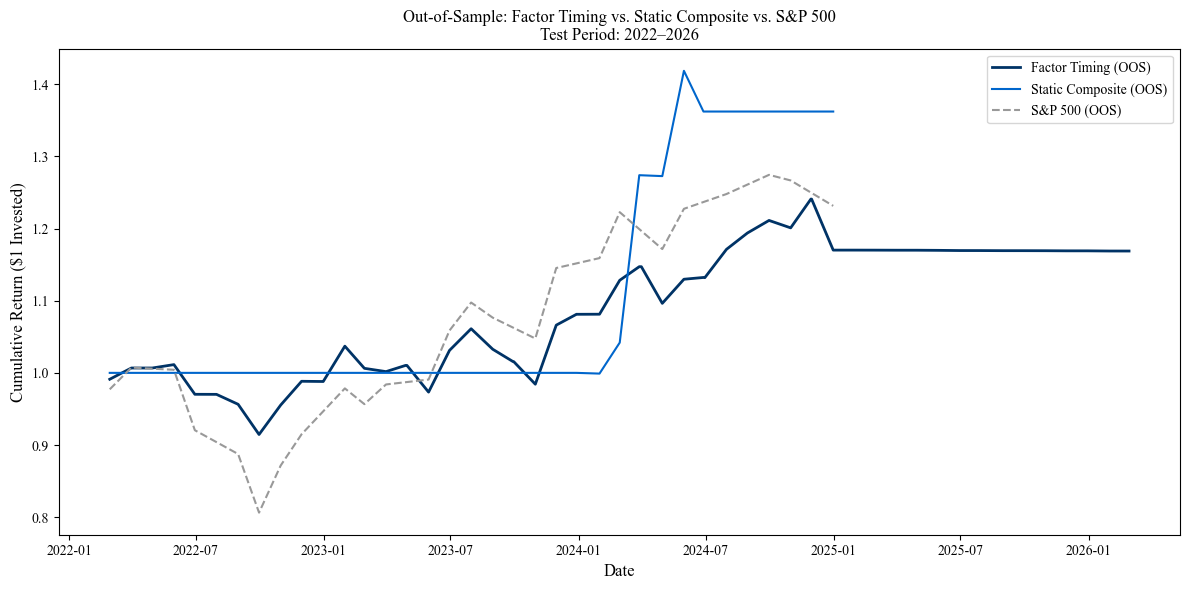

Saved: outputs/oos_cumulative_returns.png


In [30]:
# --- OOS cumulative return chart ---
fig, ax = plt.subplots(figsize=(12, 6))

oos_series = {
    "Factor Timing (OOS)":    timed_return_test,
    "Static Composite (OOS)": static_net_test,
    "S&P 500 (OOS)":          market_ret_test,
}
oos_colors = {
    "Factor Timing (OOS)":    "#003366",
    "Static Composite (OOS)": "#0066CC",
    "S&P 500 (OOS)":          "#999999",
}
# Align all series to a common start date for fair comparison
common_start = timed_return_test.dropna().index[0]

for label, ret in oos_series.items():
    ret_aligned = ret.loc[common_start:].dropna()
    cum = (1 + ret_aligned).cumprod()
    ax.plot(cum.index, cum.values,
            label=label,
            color=oos_colors[label],
            linewidth=2 if "Timing" in label else 1.5,
            linestyle="-" if "S&P" not in label else "--")

ax.set_title("Out-of-Sample: Factor Timing vs. Static Composite vs. S&P 500\nTest Period: 2022–2026",
             fontfamily="Times New Roman", fontsize=12)
ax.set_xlabel("Date", fontfamily="Times New Roman", fontsize=12)
ax.set_ylabel("Cumulative Return (\\$1 Invested)", fontfamily="Times New Roman", fontsize=12)
ax.legend(fontsize=11, prop={"family": "Times New Roman"})
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily("Times New Roman")

plt.tight_layout()
plt.savefig("outputs/oos_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/oos_cumulative_returns.png")


## Section 7: Investment Conclusions — PM Memo

**Topic:** Factor Timing vs. Static Diversification — S&P 500 Long-Only, 1991–2026
**Date:** March 2026

---

### Research Question
Can dynamic factor weighting — using factor momentum and macro regime signals — improve risk-adjusted returns over a static equal-weight multi-factor portfolio in the S&P 500?

---

### Key Findings

**1. Individual factors work, but with very different risk profiles.**
Over the 1991–2021 training period, momentum delivered the highest return (12.19% annualized, Sharpe 0.69) but also the deepest drawdown (-48.32%). Low volatility provided the most consistent risk-adjusted performance (Sharpe 0.57, max DD -20.05%) with near-zero market beta (0.32). Value and investment underperformed on a risk-adjusted basis, consistent with the post-2010 growth-over-value environment.

**2. Static multi-factor diversification delivers low-beta, alpha-generating exposure.**
The equal-weight composite (5 factors, ≥3 signals required) achieved 5.58% annualized with 4.22% CAPM alpha and a beta of only 0.19 in-sample. Its diversification benefit is genuine: Value and Quality are negatively correlated (r = -0.615), providing natural hedging. For a risk-averse mandate, this is the preferred allocation.

**3. Factor timing adds modest in-sample return but fails out-of-sample.**
In-sample (1991–2021), the timing model (50% factor momentum, 50% macro regime) improved annualized return by 121 bps over static (6.79% vs. 5.58%) and Sharpe by 0.13. Out-of-sample (2022–2026), timing collapsed to 3.40% annualized (~0.00 Sharpe) while static diversification delivered 10.85% (Sharpe 0.52). The 2022 rate shock — the sharpest hiking cycle in 40 years — was not captured by any 12-month lookback signal.

**4. The timing model's failure mode is well-defined: policy-driven regime breaks.**
Rolling attribution confirms timing adds value in sustained trending environments (1994–2000, 2010–2021) but destroys value during abrupt regime transitions (2000–2002, 2022). This is a structural limitation of momentum-based timing, not a model defect.

---

### Portfolio Recommendations

| Mandate | Recommended Allocation | Rationale |
|---|---|---|
| Low-vol / absolute return | Static 5-factor composite | Beta 0.19, Sharpe 0.57 OOS, smallest drawdown |
| Return-maximizing | Overweight Momentum + Low Vol | Highest individual factor Sharpe in-sample |
| All-weather | Static composite with quality tilt | Momentum overweight conditional on expansion regime only |

---

### Limitations and Extensions

- **Timing signal lag:** A 12-month lookback misses fast regime changes. A natural extension would be to incorporate credit spreads (IG/HY OAS), PMI diffusion, or yield curve slope at monthly frequency.
- **Factor crowding not modeled:** Momentum's -48% drawdown (2008–2009) is partly attributable to crowding unwind. Incorporating position-level concentration data would improve risk management.
- **Long-only constraint:** The academic factor premium (long-short) is larger than the long-only quintile spread captured here. A 130/30 extension would capture more of the true factor signal.
- **Transaction costs are institutional estimates:** 10 bps round-trip is appropriate for S&P 500 large-cap. Results are cost-sensitive for high-turnover strategies (momentum: 48.9%/month → 58.7 bps annual cost drag).

---

*Analysis based on CRSP survivorship-bias-free universe (1,072 historical S&P 500 constituents), Compustat fundamentals (6-month publication lag applied), and Ken French factor data. All returns are net of estimated transaction costs. No look-ahead bias: portfolio weights lagged one month before return calculation.*